# Tutorial 1: Quickstart Scientific Taste

Estimated time: 20-30 minutes

## Prerequisites
No optional dependencies required — any tutorial environment runs T1. (If you plan to work through the whole series, `py312_bayesmm_all` is the one env that runs every notebook.)

## Learning aims
- Primary package aim: drive `validate → plan → run → runs show` on a typed spec, and read the three artifacts a sweep writes
- Secondary scientific aim: tell an **additive** response apart from an **interaction** response on a full-factorial grid, and say what that distinction implies for any surrogate you later fit

## Success criteria
- you can name the five spec blocks and the columns of `sweep_rows.csv`
- you can point at the two heatmaps and say which surface a model linear in `a` and `b` represents *exactly*, and which one it cannot represent *at all*

## Why this tutorial matters

This is the smallest possible loop through the framework's **execution half** — spec → DOE → sweep → one centralized table. The other half (surrogate → coupling → joint metamodel) starts in T5; that is where the word *Bayesian* in the project name finally does some work, and where `meta sample --method propagate` vs `--method joint` (T7–T8) decides what the output numbers even mean. Everything downstream reads the CSV you produce here, so getting this loop into your fingers is worth twenty minutes.

**A sweep is not a plot — it is how you turn a slow model into *data*.** Nine rows of (`a`, `b`) → (`y[0]`, `y[1]`) are a training set: in T5 you fit a probabilistic surrogate to exactly this table so you can predict at inputs you never ran, and in module 7–T8 several such surrogates get coupled into one joint metamodel without re-running any simulator. That is why the framework centralizes every sweep into one CSV with full provenance instead of leaving results scattered across per-run directories.

No priors or posteriors appear in T1: this toy is deterministic, so one run per point gives the exact value and there is nothing to be uncertain about. Uncertainty enters in T5, when you stop *running* the model and start *predicting* it. Doing the loop once on a closed-form toy means you'll recognize the shape in T2, where the inputs become reaction rates and the output becomes a time-series.

## Step 0: Set up, and read the spec before you run it

In [1]:
# Cross-platform setup (Windows / macOS / Linux) — no shell, no PYTHONPATH prefix.
# Find the repo root so `src/` is importable, then load the shared tutorial helpers.
import sys
from pathlib import Path

_root = Path.cwd().resolve()
while not (_root / "src" / "bayesian_metamodeling").is_dir() and _root != _root.parent:
    _root = _root.parent
if str(_root / "src") not in sys.path:
    sys.path.insert(0, str(_root / "src"))

from bayesian_metamodeling.tutorial import bootstrap, run_mm_cli

root = bootstrap()  # chdir to repo root + ensure src/ on sys.path (idempotent)
ROOT = root
print("Repo root:", root)

Repo root: /Users/barak/git/metamodeling


This is a **spec-driven** framework: one typed JSON file is the entire contract between you and the runner. The toy spec is 40 readable lines, and every block maps to one arrow of T0's data-flow diagram.

| Spec block | What it decides | Arrow in the T0 diagram |
|---|---|---|
| `model.artifact` | what actually gets executed (`entrypoint`) | Spec |
| `io_schema` | the names, units and legal ranges (`support`) of every input and output | Spec |
| `design` | which points get run — here a 3×3 `grid` | DOE plan (T4) |
| `adapter` | how a design point becomes a process invocation, and how outputs come back | Sweep |
| `storage.root` | where the sweep artifacts land | `sweep_rows.csv` |

**The `adapter` block is the part you rewrite to wrap your own simulator**, so read its two lists closely in the output below:

- `{"var": "a", "to": {"kind": "cli_arg", "key": "--a"}}` means the runner will invoke `python -m examples.toy_program.run --a 1.0 --b 2.0 --run-dir <point dir>` (the `--run-dir` argument is appended by the adapter itself, so every point gets its own directory).
- `{"var": "y", "from": {"kind": "file", "path": "out/y.json"}}` means it will read the model's output back from `<point dir>/out/y.json`.

Wrapping *your* model in this framework is, to a first approximation, writing those two lists.

One thing to notice now, because it shapes the table you'll read in Step 3: `io_schema.outputs` declares **one** output — `y`, of `type: array`. The toy returns two numbers, but they are two elements of that single array, not two outputs.

In [2]:
SPEC_PATH = "tutorials/specs/model.toy.grid.json"

print(Path(SPEC_PATH).read_text())

{
  "schema_version": "1.0",
  "model": {
    "name": "toy_program_tutorial",
    "version": "0.1.0",
    "artifact": {
      "type": "local",
      "entrypoint": ["python", "-m", "examples.toy_program.run"]
    }
  },
  "runner": {
    "mode": "local_process",
    "resources": { "cpus": 1, "mem_gb": 1, "walltime_min": 1 }
  },
  "io_schema": {
    "inputs": [
      { "name": "a", "type": "float", "units": "a.u.", "support": [0.0, 2.0] },
      { "name": "b", "type": "float", "units": "a.u.", "support": [0.0, 2.0] }
    ],
    "outputs": [
      { "name": "y", "type": "array", "dims": ["index"], "units": "a.u." }
    ]
  },
  "design": {
    "strategy": "grid",
    "grid": { "a": [0.0, 1.0, 2.0], "b": [0.0, 1.0, 2.0] }
  },
  "adapter": {
    "id": "python_cli_adapter_v1",
    "input_mapping": [
      { "var": "a", "to": { "kind": "cli_arg", "key": "--a" } },
      { "var": "b", "to": { "kind": "cli_arg", "key": "--b" } }
    ],
    "output_mapping": [
      { "var": "y", "from": { "ki

## Step 1: Validate and plan

**`validate` and `plan` are two distinct read-only steps**, intentionally separated:

- **`validate`** checks each block's *shape* — types, required fields, and rules *within* a block (e.g. `design.grid` must be present when `strategy` is `grid`; `support` must be `[min, max]` with `max > min`; an `array` output must declare `dims`). It runs no model.
- **`plan`** enumerates the actual DOE points the spec will produce, still without executing anything. Use it to budget the work before launching it (9 points here; a real biological sweep can be thousands) — and, as the cell after next shows, to catch a class of error `validate` structurally cannot see.

Do them in this order: first check the spec is well-formed, then look at what it will actually do, then launch.

In [3]:
_ = run_mm_cli("validate", SPEC_PATH)
_ = run_mm_cli("plan", SPEC_PATH)

$ bayesmm validate tutorials/specs/model.toy.grid.json
Spec validation passed: model=toy_program_tutorial, strategy=grid, adapter=python_cli_adapter_v1
$ bayesmm plan tutorials/specs/model.toy.grid.json
Plan points: 9
Preview:
1: {'a': 0.0, 'b': 0.0}
2: {'a': 0.0, 'b': 1.0}
3: {'a': 0.0, 'b': 2.0}
4: {'a': 1.0, 'b': 0.0}
5: {'a': 1.0, 'b': 1.0}


### What `validate` does *not* check

A green `validate` means *each block is well-formed*, not *the blocks agree with each other*. There is no cross-block validator in `ModelSpec` (`src/bayesian_metamodeling/spec/modelspec.py`) — every rule lives inside one sub-block. So all of these pass validation today:

- a `design.grid` keyed on a variable that does not exist in `io_schema.inputs`;
- a grid value outside the variable's own declared `support`;
- an `adapter.input_mapping` entry for a variable nobody declared.

The next cell breaks the spec in the first way — in memory; the file on disk is untouched — and shows both halves of the story: `validate` is happy, and `plan` cheerfully enumerates points over `c` while `b` silently disappears.

Launching it would not save you either: the run dispatches every point and then dies in the storage layer with `KeyError: 'b'` while writing the table. **So read `plan`'s output; never trust `validate` alone.** T3 is a whole tutorial on reading validator output — this is the part the validator will never tell you.

In [4]:
import copy
import json

from bayesian_metamodeling.designs.planner import plan_points, render_plan_preview
from bayesian_metamodeling.spec import load_and_validate_modelspec

broken = copy.deepcopy(json.loads(Path(SPEC_PATH).read_text()))
broken["design"]["grid"] = {"a": [0.0, 1.0], "c": [0.0, 1.0]}  # 'c' is not an io_schema input

broken_spec = load_and_validate_modelspec(broken)  # <- does NOT raise
print("validate: OK — no cross-block check happened\n")

broken_points = plan_points(broken_spec)
print(render_plan_preview(broken_points))
print("\nvariables actually planned :", sorted({k for pt in broken_points for k in pt}))
print("variables declared as inputs:", [v.name for v in broken_spec.io_schema.inputs])

validate: OK — no cross-block check happened

Plan points: 4
Preview:
1: {'a': 0.0, 'c': 0.0}
2: {'a': 0.0, 'c': 1.0}
3: {'a': 1.0, 'c': 0.0}
4: {'a': 1.0, 'c': 1.0}

variables actually planned : ['a', 'c']
variables declared as inputs: ['a', 'b']


## Step 2: Execute the sweep, and find it in the run registry

In [5]:
from bayesian_metamodeling.storage import list_registered_runs, show_registered_run

_before = {item["run_id"] for item in list_registered_runs()}
_ = run_mm_cli("run", SPEC_PATH)
_after = {item["run_id"] for item in list_registered_runs()}

_new = sorted(_after - _before)
assert len(_new) == 1, f"expected exactly one newly registered run, got {_new}"
run_id = _new[0]

print(f"\nThis notebook's run id : {run_id}")
print(f"Runs in the registry   : {len(_after)}  (this repo, every tutorial, all time)")

$ bayesmm run tutorials/specs/model.toy.grid.json
Running point 1/9: {'a': 0.0, 'b': 0.0}
Running point 2/9: {'a': 0.0, 'b': 1.0}
Running point 3/9: {'a': 0.0, 'b': 2.0}
Running point 4/9: {'a': 1.0, 'b': 0.0}
Running point 5/9: {'a': 1.0, 'b': 1.0}
Running point 6/9: {'a': 1.0, 'b': 2.0}
Running point 7/9: {'a': 2.0, 'b': 0.0}
Running point 8/9: {'a': 2.0, 'b': 1.0}
Running point 9/9: {'a': 2.0, 'b': 2.0}
Stored sweep run: 72a73cdbf37d491494c172c6c3cf2e1a
Run complete: 9 successful runs

This notebook's run id : 72a73cdbf37d491494c172c6c3cf2e1a
Runs in the registry   : 139  (this repo, every tutorial, all time)


### The run registry

`tmp/run_registry.json` maps every run id this repo has ever produced to its record file. It is **global by design**: it accumulates across tutorials and sessions, because provenance is only useful if it outlives the session that produced it. `bayesmm runs list` prints the whole thing — it is long, and it grows every time anyone re-runs any notebook — so above we printed the count and, more usefully, the one id that *this* execution just created.

That id is what pins the rest of the notebook (including the self-check at the bottom) to **your** sweep. It matters: T4 and T5 re-run this same spec into this same store, so "the newest sweep on disk" is not reliably yours.

## Step 3: Inspect the run record, the provenance, and the table

**You can skim the next cell's code.** It looks the run record up by id and prints it, then prints one line of the per-point log. The payload is the *output*, not the code — four of its fields are worth reading carefully, and they're annotated immediately below.

In [6]:
_ = run_mm_cli("runs", "show", run_id)

run_record = show_registered_run(run_id)
sweep_rows_path = root / run_record["sweep_rows_path"]
sweep_logs_path = root / run_record["sweep_logs_path"]
assert sweep_rows_path.exists(), f"Sweep CSV does not exist: {sweep_rows_path}"

print("\nFirst line of sweep_logs.jsonl (one JSON object per DOE point):")
print(sweep_logs_path.read_text().splitlines()[0][:300])

$ bayesmm runs show 72a73cdbf37d491494c172c6c3cf2e1a
{
  "adapter_id": "python_cli_adapter_v1",
  "artifact_digest": "be420a960ea7068ca9032a4ce21b72fd694d03bf4484388174817a89f2d41336",
  "failed_count": 0,
  "finished_at": "2026-08-11T03:29:50.490304+00:00",
  "run_id": "72a73cdbf37d491494c172c6c3cf2e1a",
  "run_type": "sweep",
  "runner_mode": "local_process",
  "seed": 123,
  "spec_digest": "ca34f0e60195e7aaef1730bb25c9341694f19cb70d7672bfbd77be6adbbe0483",
  "started_at": "2026-08-11T03:29:50.124229+00:00",
  "status": "success",
  "success_count": 9,
  "sweep_execution_mode": "serial",
  "sweep_logs_path": "tmp/tutorials/toy_store/sweeps/72a73cdbf37d491494c172c6c3cf2e1a/sweep_logs.jsonl",
  "sweep_manifest_path": "tmp/tutorials/toy_store/sweeps/72a73cdbf37d491494c172c6c3cf2e1a/sweep_manifest.json",
  "sweep_rows_path": "tmp/tutorials/toy_store/sweeps/72a73cdbf37d491494c172c6c3cf2e1a/sweep_rows.csv",
  "total_points": 9
}

First line of sweep_logs.jsonl (one JSON object per DOE poin

### Reading a provenance record

Most of those fields are bookkeeping; four carry the weight.

- **`spec_digest`** — SHA-256 of the spec JSON. Change one grid value and it changes. This is how you prove, six months later, which spec produced which numbers.
- **`artifact_digest`** — the same idea for the model artifact block (entrypoint / BioModels id), so "same spec, different model" is detectable.
- **`seed`** — recorded on every run, but note that **it does nothing here**. A `grid` DOE is deterministic; `reproducibility.seed` is only read by `plan_sobol_points` (see `designs/planner.py`). You will actually use it in T4.
- **`sweep_rows_path` / `sweep_manifest_path` / `sweep_logs_path`** — the three artifacts every sweep writes: the **data** (`sweep_rows.csv`), the **manifest** (`sweep_manifest.json`: point counts, digests, column order), and the **per-point logs** (`sweep_logs.jsonl`: one JSON object per point, with its stdout and stderr).

The last one is the recovery move worth memorizing: when a run reports "3 successful runs" out of 9, the summary line tells you only *how many* failed. The *reason* is in `sweep_logs.jsonl`, one line per point.

### The table itself

Ten lines — a header and one row per DOE point. This file is the handoff to everything downstream; T5's surrogate reads exactly this. Its columns come in three groups:

- **`point_index` and the inputs** (`a`, `b`) — one column per `io_schema.inputs` entry, filled in from the DOE plan.
- **the outputs, flattened.** The spec declares one array output `y`; a list of scalars is written as `y__0, y__1, …`. Anything that cannot be flattened that way (a list of lists, a mixed dict) is JSON-encoded into a single `y__json` column instead. That naming rule (`storage/sweep_store.py`) is what you will need the first time your own model returns something structured.
- **the bookkeeping** — `status`, `returncode`, `error`, `duration_sec`, `started_at`, `finished_at`.

`sum` and `product` are **our** labels for `y__0` and `y__1`; the framework does not know those names. The helper used two cells down, `load_toy_heatmap_grids`, assigns them — and it also drops every row whose `status != "success"`, which is why a failed point vanishes from a heatmap instead of showing up as a hole.

In [7]:
print(sweep_rows_path.read_text())

point_index,a,b,y__0,y__1,status,returncode,error,duration_sec,started_at,finished_at
0,0.0,0.0,0.0,0.0,success,0,,0.042011,2026-08-11T03:29:50.124229+00:00,2026-08-11T03:29:50.166240+00:00
1,0.0,1.0,1.0,0.0,success,0,,0.040011,2026-08-11T03:29:50.166896+00:00,2026-08-11T03:29:50.206907+00:00
2,0.0,2.0,2.0,0.0,success,0,,0.039224,2026-08-11T03:29:50.207556+00:00,2026-08-11T03:29:50.246780+00:00
3,1.0,0.0,1.0,0.0,success,0,,0.039851,2026-08-11T03:29:50.247439+00:00,2026-08-11T03:29:50.287290+00:00
4,1.0,1.0,2.0,1.0,success,0,,0.039608,2026-08-11T03:29:50.287906+00:00,2026-08-11T03:29:50.327514+00:00
5,1.0,2.0,3.0,2.0,success,0,,0.040665,2026-08-11T03:29:50.328130+00:00,2026-08-11T03:29:50.368795+00:00
6,2.0,0.0,2.0,0.0,success,0,,0.039609,2026-08-11T03:29:50.369454+00:00,2026-08-11T03:29:50.409063+00:00
7,2.0,1.0,3.0,2.0,success,0,,0.040021,2026-08-11T03:29:50.409711+00:00,2026-08-11T03:29:50.449732+00:00
8,2.0,2.0,4.0,4.0,success,0,,0.039934,2026-08-11T03:29:50.450370+00:00,2026-08-11T

## Step 4: Visualize the centralized sweep outputs as two heatmaps

**Predict before you run.** Sketch on paper (or visualize mentally) what `y__0 = a + b` and `y__1 = a · b` look like as heatmaps over `a, b ∈ {0, 1, 2}`. Three questions, and commit to answers before executing:

1. Where do you expect the brightest cells in each panel? The darkest?
2. Step along a single row (fix `a`, increase `b`). In which panel is that step the *same size* no matter which row you picked?
3. In which panel do the rows look like shifted copies of each other, and in which do they fan out?

Hold those predictions for 30 seconds, then run the next cell. The point of pre-prediction is calibration: when you later look at a *biological* heatmap (T2's `k_on` sweep) you'll have built the habit of expecting a shape *before* the cell runs — which is the difference between a debugged surrogate and a confused student.

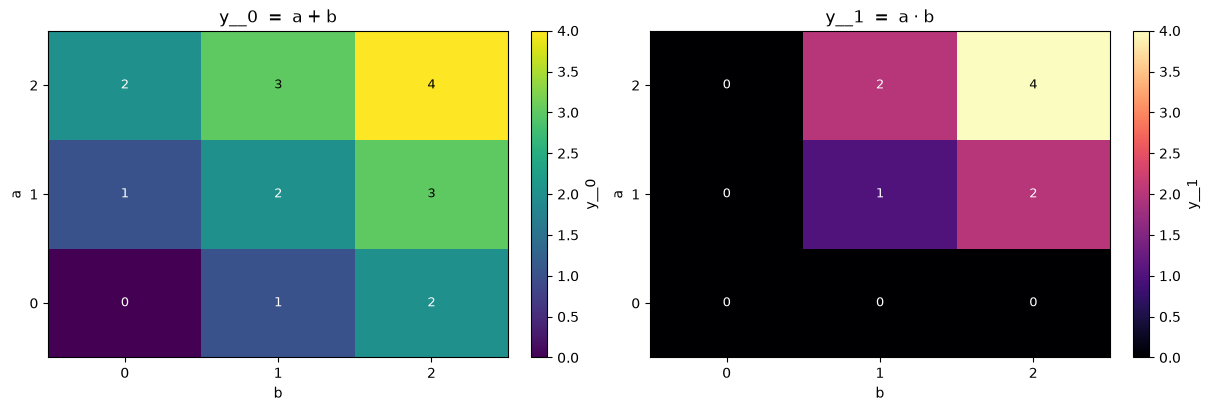

In [8]:
import matplotlib.pyplot as plt

from bayesian_metamodeling.tutorials import load_toy_heatmap_grids

# a_vals / b_vals are the sorted unique input values; the grids are indexed [a, b].
a_vals, b_vals, sum_grid, prod_grid = load_toy_heatmap_grids(sweep_rows_path)

panels = [
    (sum_grid, "viridis", "y__0  =  a + b", "y__0"),
    (prod_grid, "magma", "y__1  =  a · b", "y__1"),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for ax, (grid, cmap, title, label) in zip(axes, panels, strict=True):
    im = ax.imshow(grid, origin="lower", cmap=cmap, aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("b")  # ticks carry the VALUES of b, not indices
    ax.set_ylabel("a")
    ax.set_xticks(range(len(b_vals)), labels=[f"{v:g}" for v in b_vals])
    ax.set_yticks(range(len(a_vals)), labels=[f"{v:g}" for v in a_vals])
    for i in range(grid.shape[0]):  # annotate values so you can trace a row by eye
        for j in range(grid.shape[1]):
            bright = grid[i, j] > 0.6 * float(grid.max())
            ax.text(j, i, f"{grid[i, j]:g}", ha="center", va="center",
                    color="black" if bright else "white", fontsize=9)
    fig.colorbar(im, ax=ax, label=label)

plt.show()

## Step 5: The one property that decides whether a surrogate can work

The two panels are not merely "two functions".

- `y__0 = a + b` is **additive**: raising `a` by 1 adds 1 to the output *whatever `b` is*. The rows of the left panel are parallel — shifted copies of one another. There is no interaction between the factors.
- `y__1 = a · b` is a **pure interaction**: the effect of raising `a` depends entirely on `b` — at `b = 0`, changing `a` does nothing at all; at `b = 2` it is worth +2 per unit. The rows fan out.

That is standard design-of-experiments language, and the 3×3 grid you just ran is a *full factorial* in two factors — every combination of levels. (Two levels per factor would already let you estimate an interaction: 4 points, 4 coefficients. Three levels is the smallest design that can additionally tell a *curved* response from a straight one, which is why the toy uses three.)

Why this matters more than the arithmetic: the surrogate you fit in T5 is `pymc_gp`, which — **despite the name** — is not a Gaussian process at all. `surrogates/backends.py::_fit_pymc_bayesian_linear` builds `intercept ~ Normal(0, 2)`, `beta ~ Normal(0, 2)`, `mu = intercept + x @ beta`: Bayesian **linear regression**, no kernel, no covariance function anywhere. A model of that class represents an additive surface *exactly* and an interaction *not at all*. That is **structural misspecification** — a mismatch between the model class and the shape of the truth — and, unlike sampling noise, it is not something more data fixes.

The cell below measures all of it: the best possible plane `c + β_a·a + β_b·b` fit to each channel by least squares, the same fit with one extra `a·b` term, and — since we know the toy's closed form — what the plane would do on a 41×41 sweep of the same box, without paying for one.

In [9]:
import numpy as np

A, B = np.meshgrid(a_vals, b_vals, indexing="ij")  # same [a, b] indexing as the grids
plane = np.column_stack([np.ones(A.size), A.ravel(), B.ravel()])
plane_plus_ab = np.column_stack([plane, (A * B).ravel()])


def _worst_residual(design: np.ndarray, y: np.ndarray) -> tuple[np.ndarray, float]:
    """Least-squares fit; return coefficients and the largest absolute residual."""
    coef, *_ = np.linalg.lstsq(design, y, rcond=None)
    return coef, float(np.max(np.abs(y - design @ coef)))


plane_resid: dict[str, float] = {}
interaction_resid: dict[str, float] = {}
plane_coef: dict[str, np.ndarray] = {}

for name, grid in [("y__0", sum_grid), ("y__1", prod_grid)]:
    y = grid.ravel()
    plane_coef[name], plane_resid[name] = _worst_residual(plane, y)
    _, interaction_resid[name] = _worst_residual(plane_plus_ab, y)
    c = plane_coef[name]
    print(
        f"{name}: best plane = {c[0]:+.3f} {c[1]:+.3f}·a {c[2]:+.3f}·b"
        f"   |  worst residual: plane {plane_resid[name]:>8.3g}"
        f"   plane + a·b {interaction_resid[name]:.3g}"
    )

_intercept = float(plane_coef["y__1"][0])
print(
    f"\nAt (a, b) = (0, 0) the best plane predicts y__1 = {_intercept:+.2f}, "
    f"while the model returns {prod_grid[0, 0]:.2f}."
)
print("A negative product of two non-negative numbers: the miss is structural, not statistical.")

# Would a denser sweep help? We know the toy's closed form, so we can answer without
# running 1681 more points: fit the same plane to a 41x41 grid of a*b over the same box.
_dense = np.linspace(float(a_vals.min()), float(a_vals.max()), 41)
_dA, _dB = np.meshgrid(_dense, _dense, indexing="ij")
_dense_design = np.column_stack([np.ones(_dA.size), _dA.ravel(), _dB.ravel()])
_, dense_plane_resid = _worst_residual(_dense_design, (_dA * _dB).ravel())
print(
    f"Same plane fit to a 41x41 sweep of a·b: worst residual {dense_plane_resid:.3g} "
    f"(3x3 gave {plane_resid['y__1']:.3g}). More points, identical miss."
)

y__0: best plane = -0.000 +1.000·a +1.000·b   |  worst residual: plane 1.78e-15   plane + a·b 2.66e-15
y__1: best plane = -1.000 +1.000·a +1.000·b   |  worst residual: plane        1   plane + a·b 3.55e-15

At (a, b) = (0, 0) the best plane predicts y__1 = -1.00, while the model returns 0.00.
A negative product of two non-negative numbers: the miss is structural, not statistical.
Same plane fit to a 41x41 sweep of a·b: worst residual 1 (3x3 gave 1). More points, identical miss.


## Scientific checkpoint

Sixty seconds, answers below. A student who understood can do these from memory; one who only ran cells cannot.

1. Trace the middle row of each heatmap. In which panel is the step from `b = 0 → 1` the same size as `b = 1 → 2` **and** the same in every row? What is that property called — and in the other panel, what does the step size depend on?
2. Name the five blocks of the spec you validated, and the pipeline arrow each one feeds.
3. Which file will T5's surrogate read, and what are its column names?
4. What did `plan` tell you that `validate` could not?
5. `pymc_gp` is a Bayesian *linear* regression. Which channel can it represent exactly, which can it not represent at all — and would sweeping a 41×41 grid instead of 3×3 change that answer?

**Answers.** (1) The left panel, `y__0 = a + b`: the step is +1 everywhere, in every row — **additivity**, i.e. no interaction. In the right panel the step from `b = 0 → 1` equals that row's `a`, so one factor's effect depends on the other: **interaction**. (2) `model.artifact` → what gets executed; `io_schema` → variable names, units, support; `design` → which points (the DOE arrow, T4); `adapter` → design point → process invocation, and outputs back; `storage.root` → where the sweep lands. (3) `sweep_rows.csv`, with columns `point_index, a, b, y__0, y__1, status, returncode, error, duration_sec, started_at, finished_at`. (4) The actual DOE points — `validate` only inspects blocks in isolation, so a grid over an undeclared variable sails through it, while `plan` shows the points and the missing variable immediately. (5) `y__0` exactly — it *is* a plane. `y__1` not at all, and the last line of the cell above is the proof: 41×41 leaves the worst residual exactly where 3×3 left it, because a plane has no term that can bend. Denser sampling buys nothing against structural misspecification; a richer model class does — adding the single `a·b` term drove the residual to numerical zero.

**Hold this for T5.** You'll fit `pymc_gp` there to `y__0` — the sum — because `tutorials/specs/surrogate.toy.pymc_gp.json` sets `summary_config: {kind: index, index: 0}`, which resolves to the `y__0` column. Predict now, and write it down:

- On a channel this model class represents exactly, fit to a deterministic simulator with no noise, will the reported predictive width be large or tiny?
- Is a tiny width evidence that the prediction is trustworthy at `a = 100, b = 100`, far outside the box you swept? (Think about what a *line* does when you extend it, and about what this model has to work with that could ever make it hesitate out there.)

## Common mistakes

- Running the notebook from the wrong folder without `src/` in scope — the bootstrap cell handles this, so don't skip it.
- Treating a green `validate` as proof the spec is coherent. It checks blocks in isolation; read `plan`'s points.
- Skipping Step 2 and visualizing an old sweep. The self-check pins to *this* execution's `run_id`, so a stale sweep left by T4 or T5 cannot quietly stand in for yours.
- Assuming failed rows appear in the heatmaps. `load_toy_heatmap_grids` drops every row with `status != "success"`, so a failed point vanishes rather than showing as a hole. Check `success_count` in `sweep_manifest.json`, or the `status` column in the CSV, before believing a picture.

## Recap: what T1 established

- A **spec** is the whole contract — artifact, `io_schema`, `design`, `adapter`, `storage`. The `adapter` block is what you rewrite to wrap your own simulator.
- `validate` checks blocks in isolation; `plan` is where a nonsensical DOE becomes visible. Use both, in that order.
- A sweep writes **three** artifacts: `sweep_rows.csv` (the data), `sweep_manifest.json` (counts, digests, column order), `sweep_logs.jsonl` (per-point stdout/stderr — where the reason for a failure lives).
- Outputs are **flattened by name**: one array output `y` becomes `y__0`, `y__1`. `sum` and `product` are labels we added on top.
- **Additive vs interaction** decides whether a surrogate class can represent your model at all. You measured it rather than being told it: no plane fits `y__1`, denser sampling does not help, and one extra `a·b` term fits it exactly.

One sentence to carry forward: *the sweep is the training set, and the shape of the response decides which surrogate is even allowed to be right.*

## Final check: this run produced a real sweep, and the science is in it

Asserts that the sweep under inspection is the one **this execution** produced (T4 and T5 re-run the same spec into the same store, so "newest on disk" is not a safe proxy), that it holds the full 3×3 grid with every point successful, that the rows actually satisfy the toy model's equations, and that the interaction structure Step 5 claimed is present in the data. If this cell raises, nothing downstream — T5's surrogate fit included — has valid training data.

In [10]:
# Self-check: THIS execution's sweep exists, is complete, matches the toy equations,
# and carries the additive/interaction structure Step 5 measured.
import csv as _csv

for _needed in ("plane_resid", "interaction_resid", "dense_plane_resid"):
    assert _needed in globals(), (
        f"Step 5's least-squares cell did not run ({_needed} undefined) — "
        "the scientific claim is unverified."
    )

_rows_path = root / show_registered_run(run_id)["sweep_rows_path"]
assert _rows_path.parent.name == run_id, (
    f"self-check is reading sweep {_rows_path.parent.name}, not this notebook's "
    f"sweep {run_id} — re-run Steps 1-2."
)

with open(_rows_path) as _f:
    _rows = list(_csv.DictReader(_f))
_success = [r for r in _rows if r.get("status") == "success"]
assert len(_rows) == 9, f"Expected 9 DOE points (3x3 grid) in {_rows_path.name}, got {len(_rows)}"
assert len(_success) == 9, f"Expected 9/9 successful runs, got {len(_success)}/9 in {_rows_path}"
assert len({r["a"] for r in _rows}) == 3 and len({r["b"] for r in _rows}) == 3, (
    "Design collapsed: expected 3 distinct levels of each of a and b (a full 3x3 factorial)."
)

# The model actually computed what the heatmaps claim it computed.
for _r in _success:
    _a, _b = float(_r["a"]), float(_r["b"])
    assert abs(float(_r["y__0"]) - (_a + _b)) < 1e-9 and abs(float(_r["y__1"]) - _a * _b) < 1e-9, (
        f"Toy model equations violated at a={_a}, b={_b}: "
        f"y__0={_r['y__0']}, y__1={_r['y__1']}"
    )

# The scientific claim, not just the plumbing. Margins are wide on purpose: these are
# structural facts about the design, not properties of one machine's arithmetic.
assert plane_resid["y__0"] < 1e-9, (
    f"y__0 should be exactly planar; the best plane still misses by {plane_resid['y__0']:.3g}"
)
assert plane_resid["y__1"] > 0.5, (
    f"y__1 carries no interaction — a plane fits it to {plane_resid['y__1']:.3g}, so this "
    "sweep does not contain the structure Step 5 teaches."
)
assert interaction_resid["y__1"] < 1e-9, (
    f"Adding an a*b term should fit y__1 exactly; residual {interaction_resid['y__1']:.3g}"
)
assert dense_plane_resid > 0.5, (
    f"A 41x41 sweep should not rescue the plane, but its worst residual fell to "
    f"{dense_plane_resid:.3g} — the misspecification lesson would be wrong."
)

print(
    f"\n[T1 self-check OK] {len(_success)}/{len(_rows)} success rows in "
    f"{_rows_path.relative_to(root)}; equations verified; interaction confirmed "
    f"(plane misses y__1 by {plane_resid['y__1']:.3g} at 3x3 and "
    f"{dense_plane_resid:.3g} at 41x41; plane + a·b residual "
    f"{interaction_resid['y__1']:.3g})"
)


[T1 self-check OK] 9/9 success rows in tmp/tutorials/toy_store/sweeps/72a73cdbf37d491494c172c6c3cf2e1a/sweep_rows.csv; equations verified; interaction confirmed (plane misses y__1 by 1 at 3x3 and 1 at 41x41; plane + a·b residual 3.55e-15)
